In [19]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import glob
import os
import re
from nptdms import TdmsFile
from scipy.stats import kurtosis

## 1. Operation 데이터 EDA

In [7]:
def get_train_num(file_name):
    """파일명에서 Train 번호 추출"""
    return int(re.findall(r'\d+', file_name)[0])

def plot_life_cycle_op(base_path):
    # 라벨링된 Operation CSV 파일 탐색
    labeled_files = sorted(glob.glob(os.path.join(base_path, "Train*_Operation_labeled.csv")))
    
    if not labeled_files:
        print("❌ 라벨링된 CSV 파일을 찾을 수 없습니다. 먼저 라벨링 함수를 실행해주세요.")
        return

    for fpath in labeled_files:
        t_num = get_train_num(os.path.basename(fpath))
        print(f"📊 Analyzing Train {t_num}...")
        
        # 데이터 로드
        df = pd.read_csv(fpath)
        
        # 확정된 TTF (ttf 열의 첫 번째 값 사용)
        ttf = df['ttf'].iloc[0]
        
        # --- 시각화 설정 ---
        fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
        fig.suptitle(f'Life-cycle EDA: Train {t_num} (TTF: {ttf:.1f}s)', fontsize=16, fontweight='bold')
        
        # X축 데이터 (시간)
        time_s = df['Time[sec]']

        # 1. 온도 (Front/Rear)
        axes[0].plot(time_s, df['  TC SP Front[℃]'], label='Front Temp', color='tab:red', alpha=0.7)
        axes[0].plot(time_s, df['  TC SP Rear[℃]'], label='Rear Temp', color='tab:orange', alpha=0.7)
        axes[0].set_ylabel('Temperature [℃]', fontsize=12)
        axes[0].set_title('Bearing Temperature Trend', fontsize=14)
        axes[0].grid(True, linestyle='--', alpha=0.5)
        axes[0].legend(loc='upper left')
        # 고장 임계치(200도) 표시
        axes[0].axhline(y=200, color='red', linestyle='--', linewidth=1, label='Failure Threshold (200℃)')

        # 2. 토크
        axes[1].plot(time_s, df['  Torque[Nm]'], label='Torque', color='tab:green')
        axes[1].set_ylabel('Torque [Nm]', fontsize=12)
        axes[1].set_title('Motor Torque Trend', fontsize=14)
        axes[1].grid(True, linestyle='--', alpha=0.5)
        # 고장 임계치(-20Nm) 표시
        axes[1].axhline(y=-20, color='red', linestyle='--', linewidth=1, label='Failure Threshold (-20Nm)')

        # 3. RPM
        axes[2].plot(time_s, df['  Motor speed[rpm]'], label='RPM', color='tab:blue')
        axes[2].set_xlabel('Time [sec]', fontsize=12)
        axes[2].set_ylabel('RPM', fontsize=12)
        axes[2].set_title('Motor Speed (RPM) Trend', fontsize=14)
        axes[2].grid(True, linestyle='--', alpha=0.5)

        # --- 고장 시점(TTF) 수직선 표시 (모든 플롯에 공통) ---
        for ax in axes:
            ax.axvline(x=ttf, color='black', linestyle='-', linewidth=2, label='Failure Time (TTF)')
            # 고장 직전 1시간(3600초) 구간 강조 (선택사항)
            ax.axvspan(ttf - 3600, ttf, color='yellow', alpha=0.2, label='Near Failure (Last 1hr)')

        plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # 제목 공간 확보
        plt.show()

📊 Analyzing Train 1...


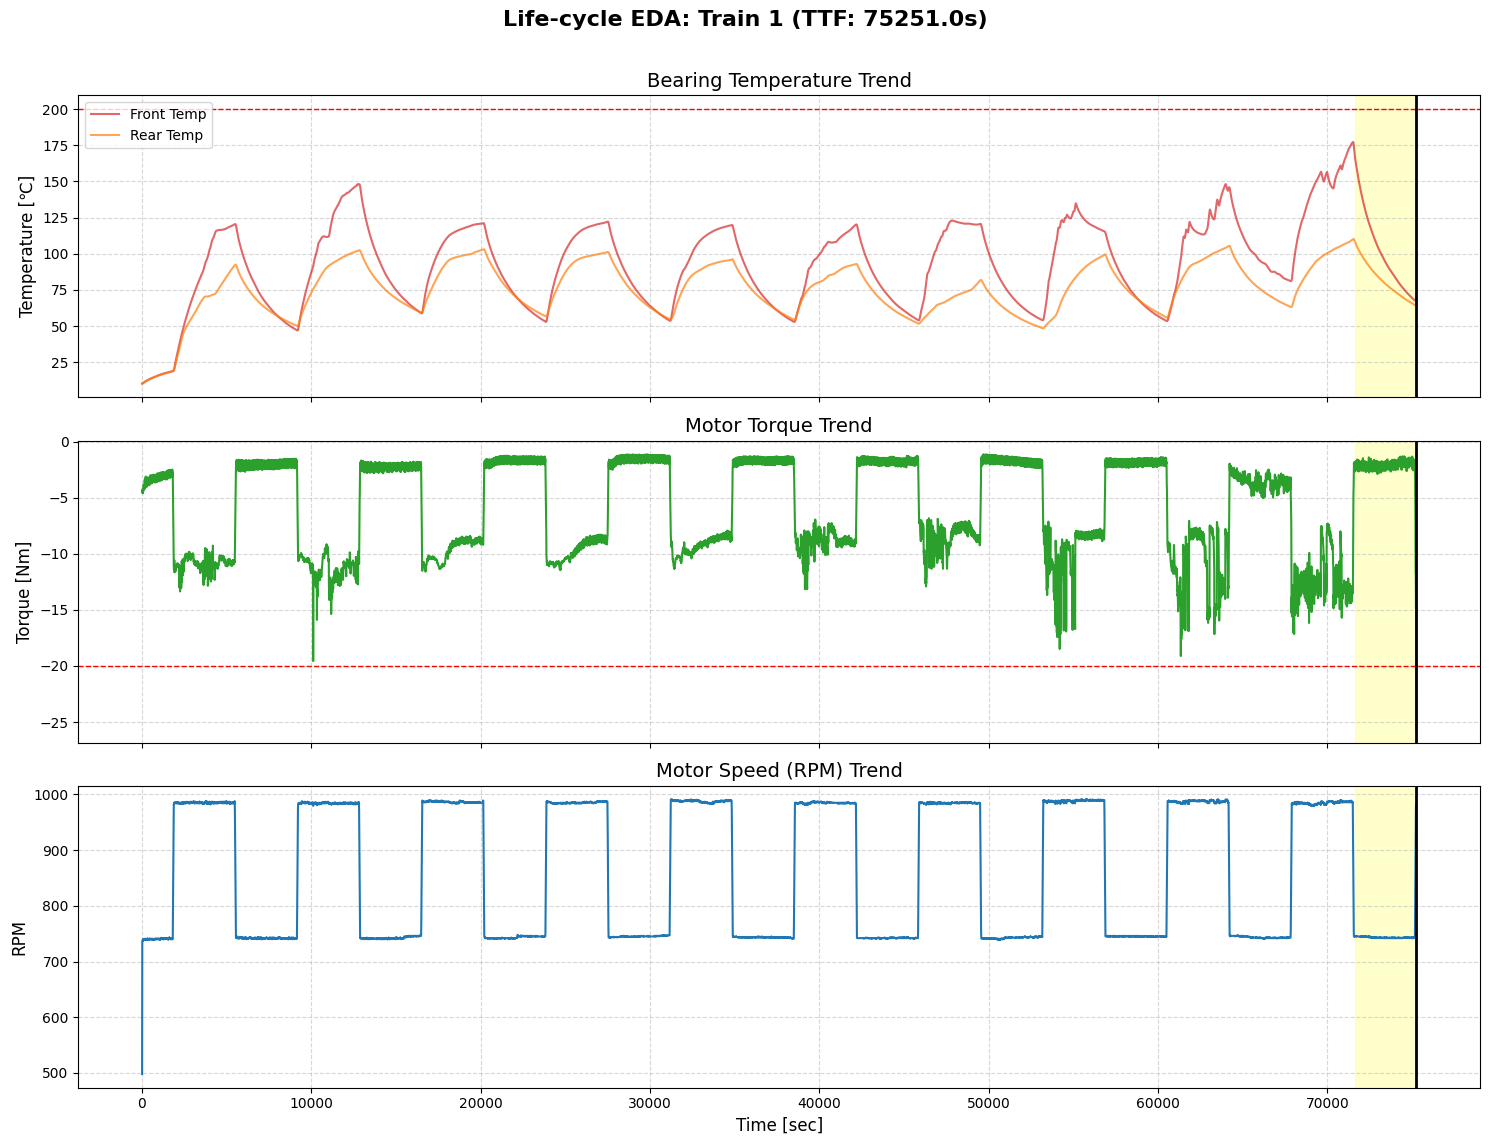

📊 Analyzing Train 2...


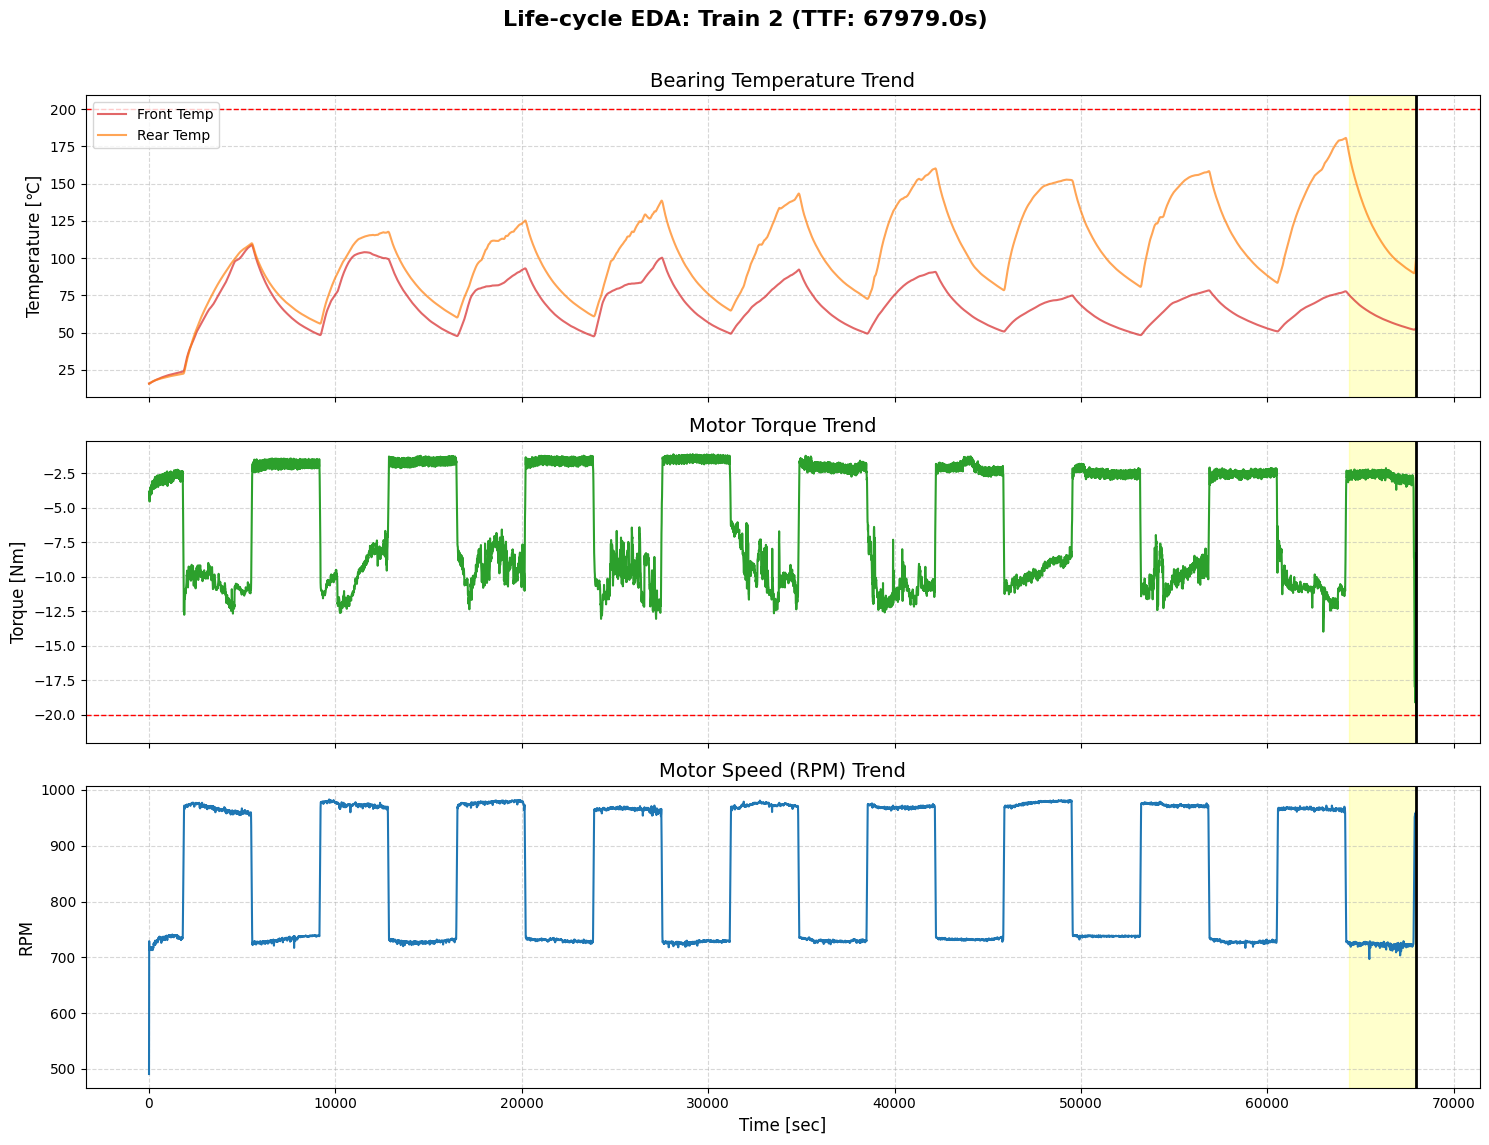

📊 Analyzing Train 3...


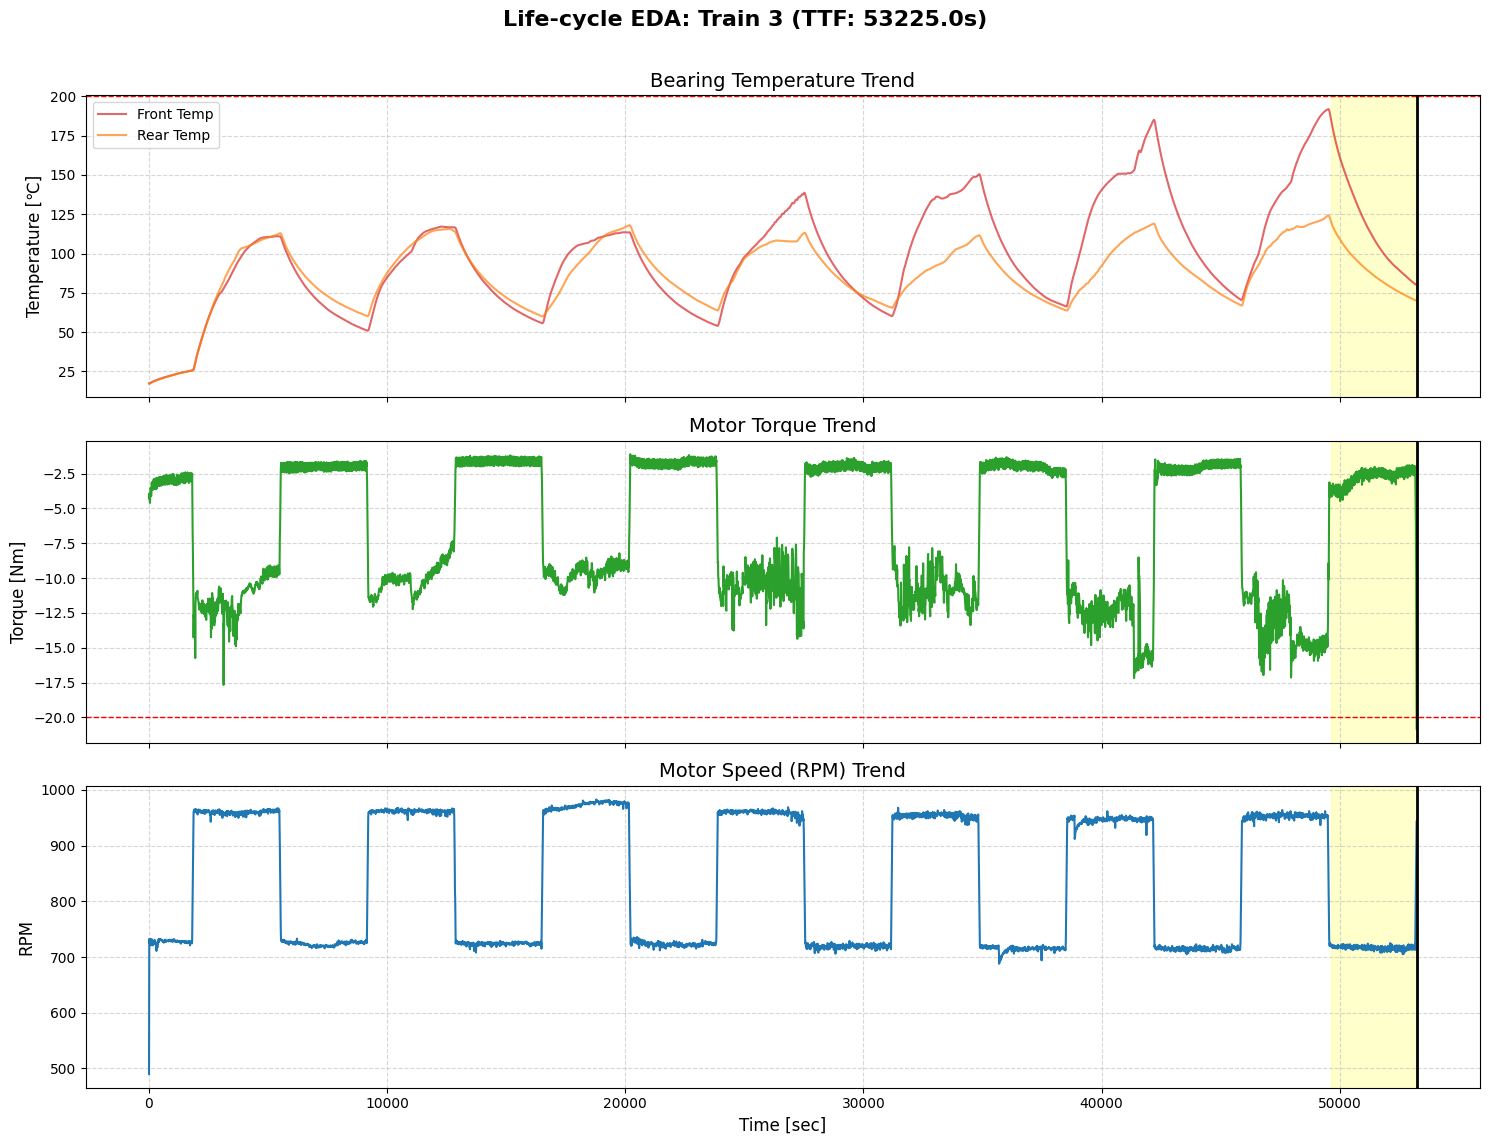

📊 Analyzing Train 4...


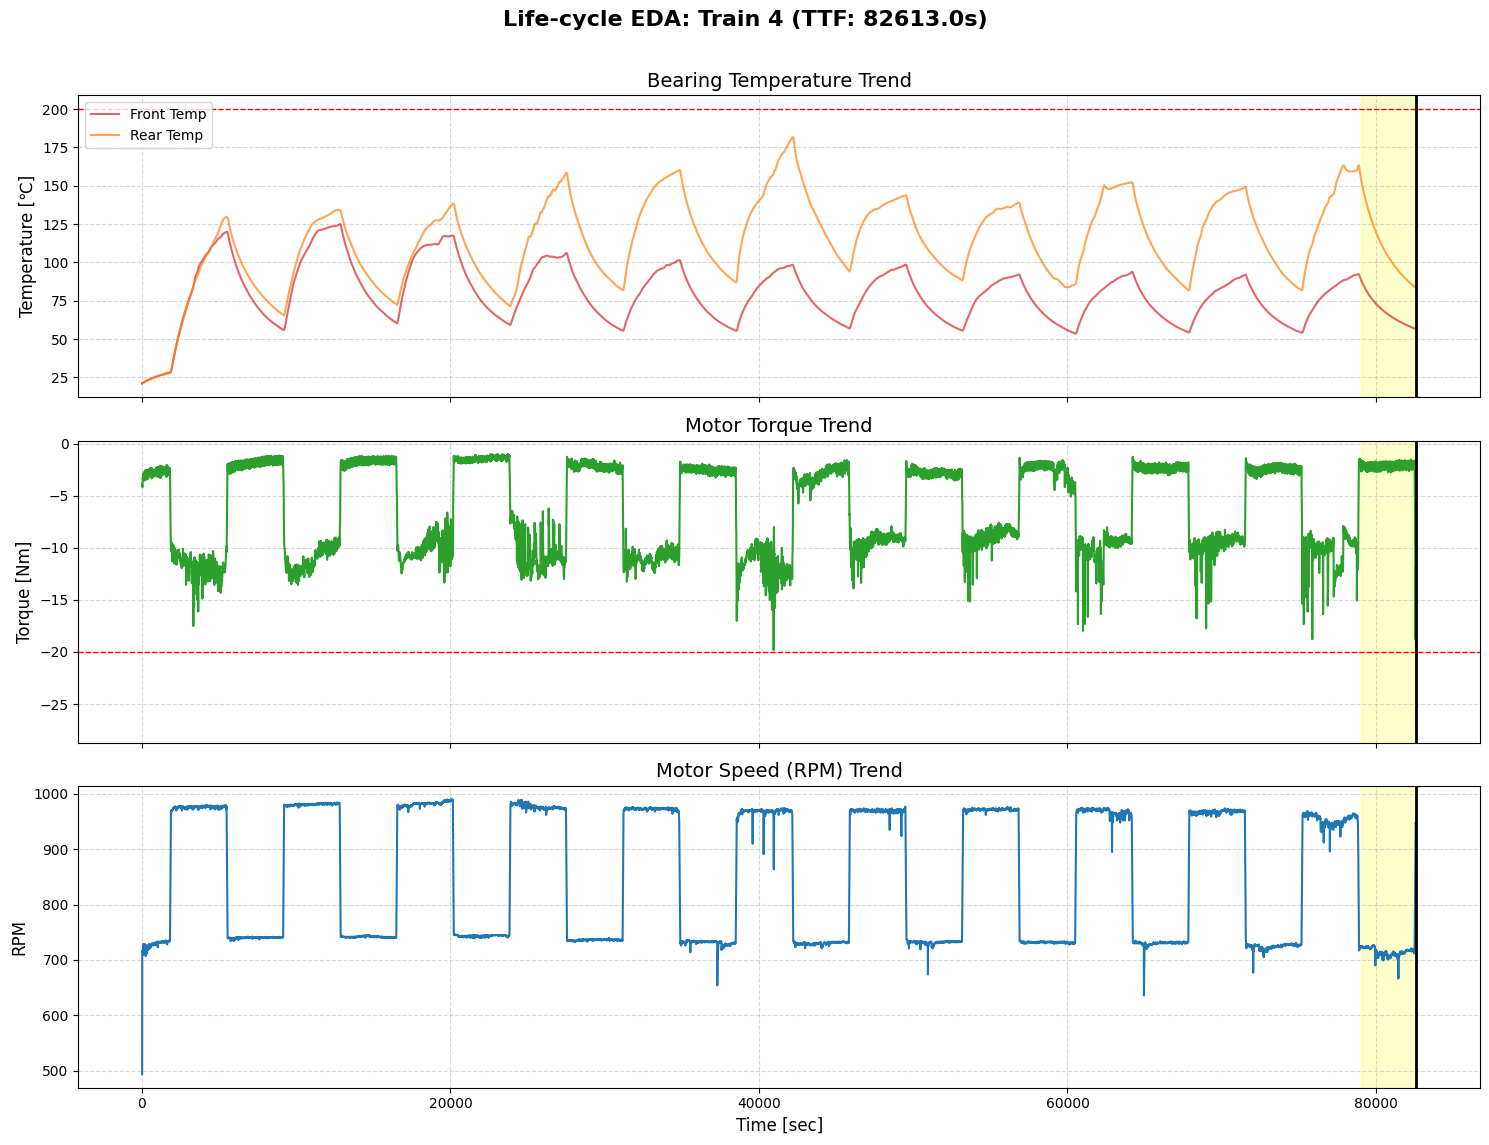

In [8]:
plot_life_cycle_op('../data/Train')

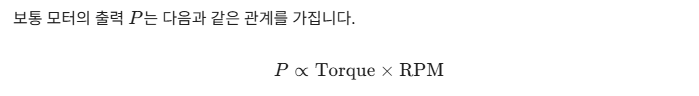

<그래프>
- Train1, 3 은 Front Temp가 Rear Temp보다 높다. : 전방 베어링의 문제 예상
- Train2, 4는 Rear Temp가 높게 형성이 된다. + Front Temp가 고장 직전 오히려 낮아진다. (왜일까?) : 후방 베어링 문제 예상 + 후방 베어링에 유격이 생기면 힘이 파손된 쪽으로 쏠려 오히려 전방에 부하 줄어들 가능성   
  
<파생 변수>
- RPM과 토크(회전력)가 반비례 관계에 있다. >> <B><U>energy = Torque * RPM</U></B> : RPM 변화와 관계없이 일정한 값을 유지하려는 성질이 있기 때문(베어링 마모로 저항이 커지면 더 강한 힘(음수 토크) 필요)
- RPM과 온도가 비례 관계에 있다. >> RPM 상승으로 인한 정상적 온도 변화와 고장으로 인한 비정상적 온도 변화를 구분하기 위해 <U><B>"RPM 대비 온도 비율"(파생 변수)</B></U> 생성
- 온도/토크의 변동 폭

## 2. 진동 데이터 EDA

- 시계열 분포 시각화(x축 : 시간, y축 : 진동 데이터)
- 첨도 산출 : 신호가 뾰족한 정도(첨도가 3을 넘기면 베어링에 미세 균열이 있다고 판단)
- 주파수 영역 분석 : RMS는 진동의 에너지량을 말해주며 BPFO, BPFI 등 특정 주파수 대역에서 에너지가 솟구친다면 이를 통해 어디가 고장인지 증명할 수 있음

### 2-1. 첫 번째와 마지막 진동 데이터 비교

In [20]:

def plot_vib_comparison(base_path, fs=25600):
    # 1. Train*_Vibration 패턴을 가진 모든 폴더 탐색
    vib_dirs = sorted(glob.glob(os.path.join(base_path, 'Train*_Vibration')))
    
    if not vib_dirs:
        print(f"⚠️ '{base_path}' 경로에서 Train*_Vibration 폴더를 찾을 수 없습니다.")
        return

    num_dirs = len(vib_dirs)
    # 폴더 개수에 맞춰 서브플롯 생성
    fig, axes = plt.subplots(num_dirs, 2, figsize=(18, 5 * num_dirs), sharey=False)
    fig.suptitle('Vibration Comparison: Healthy vs Failure (with Kurtosis)', 
                 fontsize=22, fontweight='bold', y=0.99)

    if num_dirs == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, vib_dir in enumerate(vib_dirs):
        dir_name = os.path.basename(vib_dir)
        train_label = re.search(r'Train\d+', dir_name).group()

        # 2. 해당 폴더 내 원본 TDMS 파일만 리스트업 (_labeled 제외)
        all_tdms = glob.glob(os.path.join(vib_dir, '*.tdms'))
        pure_vib_files = [f for f in all_tdms if "_labeled" not in f]
        pure_vib_files.sort(key=lambda x: int(os.path.basename(x).split('.')[0]))
        
        if not pure_vib_files:
            continue
            
        target_files = [pure_vib_files[0], pure_vib_files[-1]]
        titles = [f"{train_label} - First (Healthy)", f"{train_label} - Last (Failure)"]

        for j, fpath in enumerate(target_files):
            try:
                with TdmsFile.read(fpath) as tdms:
                    group = tdms.groups()[0]
                    channel = group.channels()[0]
                    data = channel[:]
                
                # 0.1초 데이터 시각화
                display_samples = 2560 
                t = np.arange(display_samples) / fs
                
                axes[i, j].plot(t, data[:display_samples], color='tab:blue' if j==0 else 'tab:red', linewidth=0.6)
                axes[i, j].set_title(titles[j], fontsize=15, fontweight='bold')
                axes[i, j].grid(True, alpha=0.3)
                axes[i, j].set_ylabel("Vibration [g]")
                if i == num_dirs - 1: axes[i, j].set_xlabel("Time [sec]")
                
                # --- 통계치 계산 (RMS, Peak, Kurtosis) ---
                rms = np.sqrt(np.mean(data**2))
                peak = np.max(np.abs(data))
                kurt = kurtosis(data, fisher=True) # [추가] 피셔 첨도 (정규분포=0)
                
                # [수정] 통계치 텍스트 표시
                stats_text = f'RMS: {rms:.4f}\nPeak: {peak:.2f}\nKurtosis: {kurt:.2f}'
                axes[i, j].text(0.02, 0.75, stats_text, transform=axes[i, j].transAxes, 
                                fontweight='bold', fontsize=12,
                                bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))
                
            except Exception as e:
                print(f"❌ {fpath} 읽기 오류: {e}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

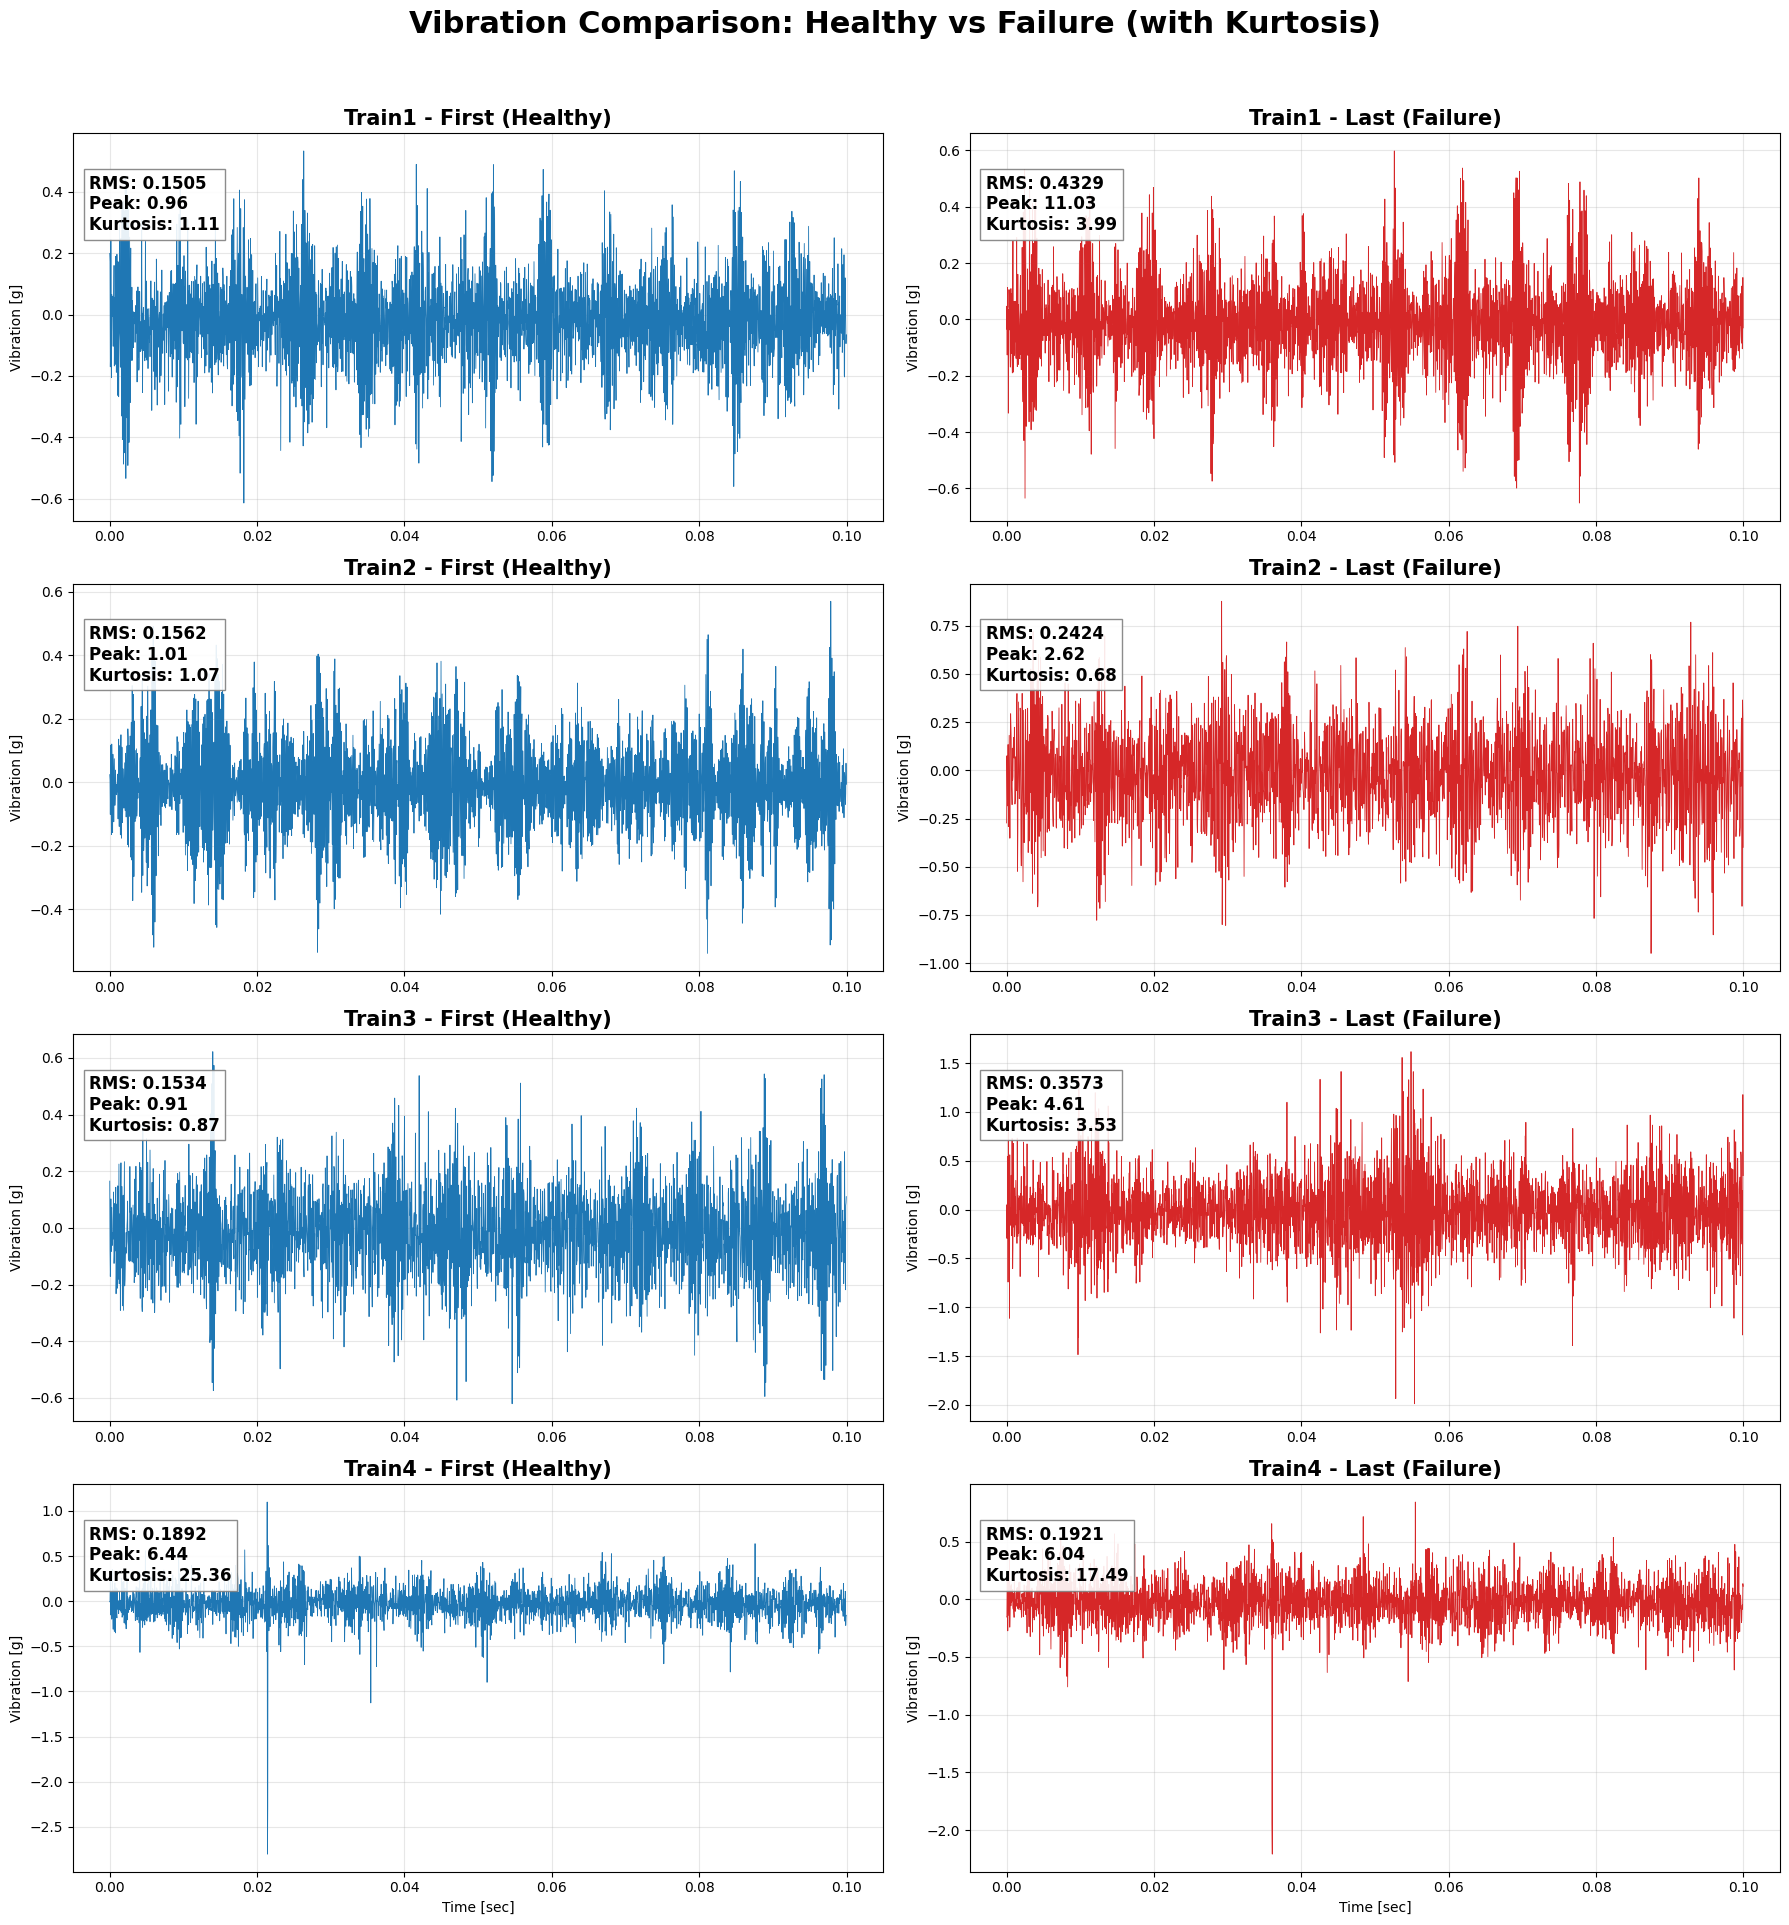

In [21]:
plot_vib_comparison('../data/Train')

> 다음에 할 일          
: 운전 데이터 피쳐 추출          
: 진동 데이터 피쳐 추출 및 요약 - 고장 주파수에 대해 더 알아보고 최종 피쳐 결정할 것         
: 운전, 진동 데이터 병합          

- 진동 데이터 고장 주파수 추출하는건 x축을 주파수로 변환하면 획득 가능

## 2. 운전 데이터 EDA
: 진동 데이터가 놓칠 수 있는 환경적 요인 설명

- RPM 변동 확인 : 진동이 커진 이유가 RPM 속도 증가 때문인지 확인 필요(진동 크기는 RPM 속도에 비례)
- 온도 및 토크 변화 확인 : 베어링이 마모되면 마찰이 심해져 온도가 오르고 토크가 변합니다. 
- 상관관계 분석 : 진동 통계치와 운전 변수 간의 상관계수를 구해 어떤 변수가 기여도가 높은지 선별